Retrieving results for number_vs_complexity_of_neuron_enwik8 from W&B
Saved 14 runs to number_vs_complexity_of_neuron_enwik8.csv


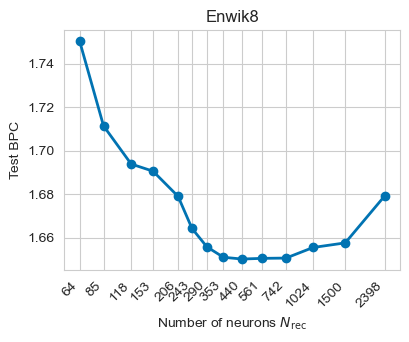

Retrieving results for number_vs_complexity_of_neuron_shd_adding from W&B
Saved 10 runs to number_vs_complexity_of_neuron_shd_adding.csv


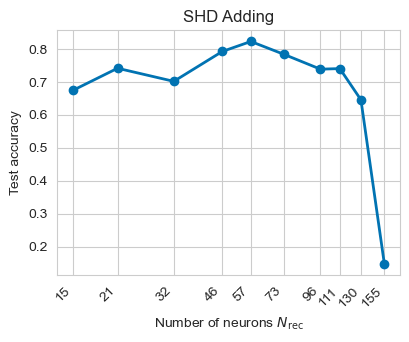

Retrieving results for neuron_complexity_ablation_neuronio from W&B
Saved 12 runs to neuron_complexity_ablation_neuronio.csv


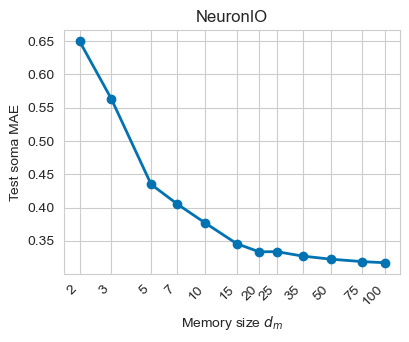

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import wandb


# ==================== imports / settings ====================

# NOTE: YOU NEED TO FILL IN YOUR PATHS
WANDB_ENTITY = "aaron_spieler"
WANDB_PROJECT = "elm_network"
RESULTS_DIR = Path.cwd()
RETRIEVE_FAILED = False

sns.set_style("whitegrid")


# ==================== helper functions ====================

def retrieve_experiment_results(
    experiment_group: str,
    entity: str = WANDB_ENTITY,
    project: str = WANDB_PROJECT,
    retrieve_failed: bool = RETRIEVE_FAILED,
):
    api = wandb.Api()
    runs = api.runs(
        f"{entity}/{project}",
        filters={"group": experiment_group},
    )

    rows = []
    for run in runs:
        if run.state == "finished" or retrieve_failed:
            rows.append(
                {
                    "State": run.state,
                    "config": {
                        k: v for k, v in run.config.items() if not k.startswith("_")
                    },
                    "summary": run.summary._json_dict,
                }
            )

    if len(rows) == 0:
        print(f"No runs found for group: {experiment_group}")
        return None

    # resolve nesting
    df = pd.json_normalize(rows)

    # remove secondary
    drop_cols = [
        col
        for col in df.columns
        if col.startswith("config.setup.")
        or col.startswith("summary.train_log.")
        or col.startswith("summary._")
    ]
    df = df.drop(columns=drop_cols, errors="ignore").copy()
    
    return df


def load_or_retrieve_results(experiment_group: str):
    csv_path = RESULTS_DIR / f"{experiment_group}.csv"

    if csv_path.exists():
        print(f"Loading cached results from {csv_path.name}")
        return pd.read_csv(csv_path)

    print(f"Retrieving results for {experiment_group} from W&B")
    df = retrieve_experiment_results(experiment_group)

    if df is None or len(df) == 0:
        return None

    df.to_csv(csv_path, index=False)
    print(f"Saved {len(df)} runs to {csv_path.name}")
    return df


def plot_single_tradeoff_experiment(
    df: pd.DataFrame,
    title: str,
    x_column: str,
    y_column: str,
    x_label: str,
    y_label: str,
    fig_size=(4.2, 3.52),
):
    df = df.copy()

    df[x_column] = pd.to_numeric(df[x_column], errors="coerce")
    df[y_column] = pd.to_numeric(df[y_column], errors="coerce")
    df = df.dropna(subset=[x_column, y_column])

    if len(df) == 0:
        raise ValueError(f"No valid rows left for plotting {title}.")

    plot_df = (
        df.groupby(x_column, as_index=False)
        .agg(
            y_mean=(y_column, "mean"),
            y_std=(y_column, "std"),
        )
        .sort_values(x_column)
    )

    color = sns.color_palette("colorblind", n_colors=1)[0]

    fig, ax = plt.subplots(figsize=fig_size)

    ax.errorbar(
        plot_df[x_column],
        plot_df["y_mean"],
        yerr=plot_df["y_std"].fillna(0.0),
        color=color,
        marker="o",
        linewidth=2,
        capsize=3,
    )
    ax.set_xscale("log")

    ax.set_xticks(plot_df[x_column].tolist())
    ax.set_xticklabels(
        [int(x) if float(x).is_integer() else x for x in plot_df[x_column].tolist()],
        rotation=45,
        ha="right",
    )

    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    plt.tight_layout()
    plt.show()


# ==================== wandb settings ====================

GROUP_ENWIK8 = "number_vs_complexity_of_neuron_enwik8"
GROUP_SHD = "number_vs_complexity_of_neuron_shd_adding"
GROUP_NEURONIO = "neuron_complexity_ablation_neuronio"


# ==================== plot 1: Enwik8 ====================

df_enwik8 = load_or_retrieve_results(GROUP_ENWIK8)
plot_single_tradeoff_experiment(
    df=df_enwik8,
    title="Enwik8",
    x_column="config.model.num_hidden",
    y_column="summary.eval_results.final_test_bpc",
    x_label=r"Number of neurons $N_{\mathrm{rec}}$",
    y_label="Test BPC",
)


# ==================== plot 2: SHD Adding ====================

df_shd = load_or_retrieve_results(GROUP_SHD)
plot_single_tradeoff_experiment(
    df=df_shd,
    title="SHD Adding",
    x_column="config.model.num_hidden",
    y_column="summary.eval_results.final_test_accuracy",
    x_label=r"Number of neurons $N_{\mathrm{rec}}$",
    y_label="Test accuracy",
)


# ==================== plot 3: NeuronIO ====================

df_neuronio = load_or_retrieve_results(GROUP_NEURONIO)
plot_single_tradeoff_experiment(
    df=df_neuronio,
    title="NeuronIO",
    x_column="config.model.num_memory",
    y_column="summary.eval_results.test_results.soma_MAE",
    x_label=r"Memory size $d_m$",
    y_label="Test soma MAE",
)
